In [54]:
import pickle
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import BisectingKMeans
import hdbscan
from sklearn.cluster import OPTICS
from sklearn.metrics.pairwise import cosine_distances
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture
import re
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
with open("df_recipes_reduced_ingredients.pkl", "rb") as f:
    df_recipes_reduced_ingredients = pickle.load(f)

with open("df_all_reviews.pkl", "rb") as f:
    df_all_reviews = pickle.load(f)

In [23]:
df_recipes_reduced_ingredients.head()

,recipe_id,name,description_x,avg_rating,num_ratings,calories,fat,sugar,sodium,protein,...,ing_olive oil,ing_onion,ing_parmesan cheese,ing_pepper,ing_salt,ing_salt and pepper,ing_sugar,ing_vanilla,ing_vegetable oil,ing_water
0,39,biryani,"delhi, india",3.00,1,1110.7,90.0,81.0,15.0,126.0,...,0,1,0,0,1,0,0,0,1,0
1,40,best lemonade,this is from one of my first good house keepi...,4.33,9,311.1,0.0,308.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
2,43,best blackbottom pie,"sweet, chocolatey, yummy",1.00,1,437.9,29.0,170.0,11.0,13.0,...,0,0,0,0,1,0,1,0,0,1
3,45,buttermilk pie with gingersnap crumb crust,yum,2.67,3,228.0,10.0,98.0,11.0,8.0,...,0,0,0,0,1,0,1,0,0,0
4,46,a jad cucumber pickle,it is a traditional accompaniment to snacks su...,5.00,2,4.3,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


# Klasterovanje nutritivnih komponenti

In [24]:
nutr_cols = cols = ["calories", "fat", "sugar", "sodium","protein", "saturated fat", "carbohydrates"]
df_nutritive = df_recipes_reduced_ingredients[nutr_cols].copy()

In [25]:
scaler = StandardScaler()
df_nutritive_scaled = scaler.fit_transform(df_nutritive)

In [26]:
pca = PCA(n_components=0.9) 
df_nutritive_pca = pca.fit_transform(df_nutritive_scaled)

In [27]:
np.cumsum(pca.explained_variance_ratio_)

array([0.60412173, 0.75823411, 0.89377078, 0.96303763])

In [28]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=df_nutritive.columns
)

loadings.sort_values("PC1", ascending=False)

,PC1,PC2,PC3,PC4
calories,0.480020,0.004838,-0.058731,0.047542
fat,0.429879,0.248854,-0.197503,-0.379328
saturated fat,0.420063,0.193243,-0.221242,-0.458431
carbohydrates,0.403268,-0.455802,0.086052,0.252381
sugar,0.369010,-0.559577,0.063192,0.153266
protein,0.295299,0.594535,0.021953,0.708716
sodium,0.149455,0.162330,0.946950,-0.232865


PC1 : svuda pretežno iste vrednosti -> ukupna energetska vrednost 

PC2 : šećer vs proteini

PC3 : sodijum (slano)

# KMeans

In [42]:
kmeans3 = KMeans(n_clusters=3, random_state=42)
clusters3 = kmeans3.fit_predict(df_nutritive_pca)
sil3 = silhouette_score(df_nutritive_pca, clusters3)


kmeans4 = KMeans(n_clusters=4, random_state=42)
clusters4 = kmeans4.fit_predict(df_nutritive_pca)
sil4 = silhouette_score(df_nutritive_pca, clusters4)

print("Silhouette k=3:", sil3)
print("Silhouette k=4:", sil4)

Silhouette k=3: 0.7713289051712995
Silhouette k=4: 0.532784791765162


In [44]:
silhouettes = []
for n in range(2,5):
    km = KMeans(n_clusters=n,n_init=100, max_iter=500, init='random')
    km.fit(df_nutritive_pca)
    s = silhouette_score(df_nutritive_pca, km.labels_, metric='euclidean')
    silhouettes.append(s)

silhouettes

[0.8722632490228153, 0.7789528720810364, 0.7652719250751924]

<StemContainer object of 3 artists>

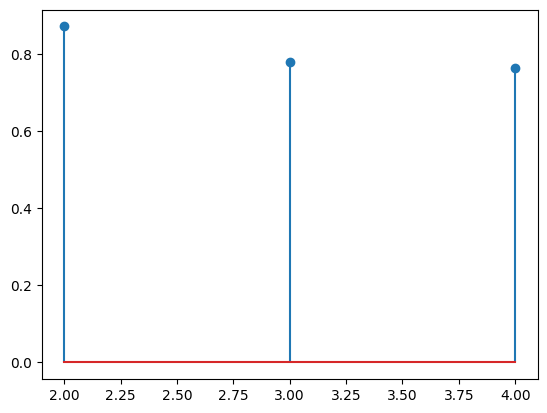

In [45]:
plt.stem(range(2,5),silhouettes)

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_nutritive_pca)
df_nutritive['cluster'] = clusters

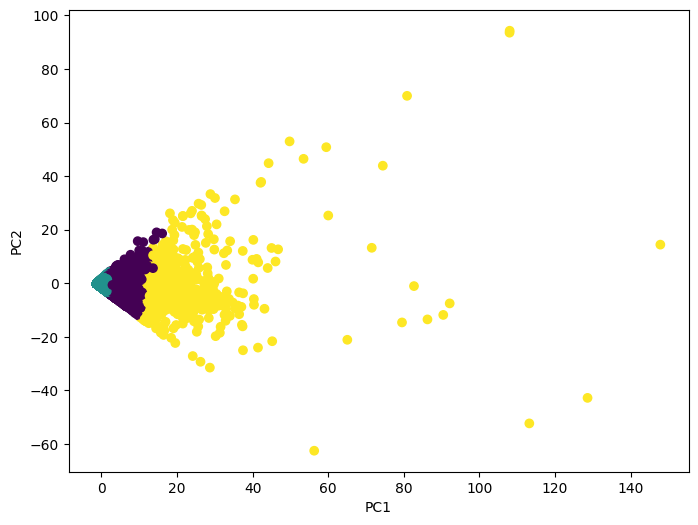

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(df_nutritive_pca[:,0], df_nutritive_pca[:,1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [11]:
pca.explained_variance_ratio_

array([0.60412173, 0.15411238, 0.13553667, 0.06926685])

Metoda lakta

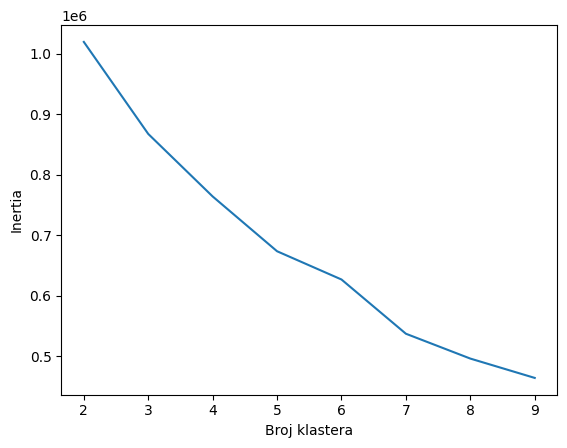

In [12]:
inertia = []
for k in range(2 ,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_nutritive_pca)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia)
plt.xlabel("Broj klastera")
plt.ylabel("Inertia")
plt.show()


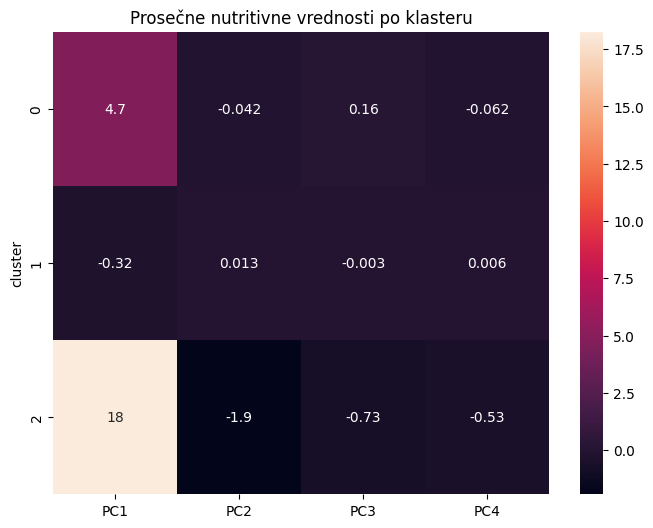

In [14]:
df_pca = pd.DataFrame(
    df_nutritive_pca,
    columns=["PC1", "PC2", "PC3", "PC4"]
)
df_pca['cluster'] = clusters
cluster_means = df_pca.groupby('cluster').mean()

plt.figure(figsize=(8,6))
sns.heatmap(cluster_means, annot=True)
plt.title("Prosečne nutritivne vrednosti po klasteru")
plt.show()

In [15]:
df_nutritive['cluster'].value_counts()

cluster
1    218464
0      9860
2      1310
Name: count, dtype: int64

# BisectingKMeans

In [30]:
bisect = BisectingKMeans(n_clusters=3, random_state=42)
labels_bisect = bisect.fit_predict(df_nutritive_pca)

df_nutritive['bisect_cluster'] = labels_bisect

In [31]:
df_nutritive['bisect_cluster'].value_counts()

bisect_cluster
2    225130
1      4047
0       457
Name: count, dtype: int64

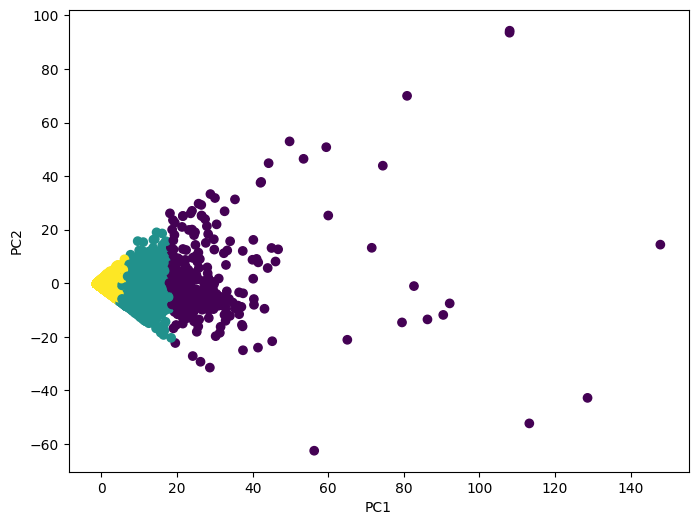

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(df_nutritive_pca[:,0], df_nutritive_pca[:,1], c=labels_bisect)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# HDBSCAN

In [32]:
#pip install hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
labels_hdb = clusterer.fit_predict(df_nutritive_pca)

df_nutritive['hdbscan_cluster'] = labels_hdb

In [33]:
df_nutritive['hdbscan_cluster'].value_counts()

hdbscan_cluster
 1    199028
-1     30376
 0       230
Name: count, dtype: int64

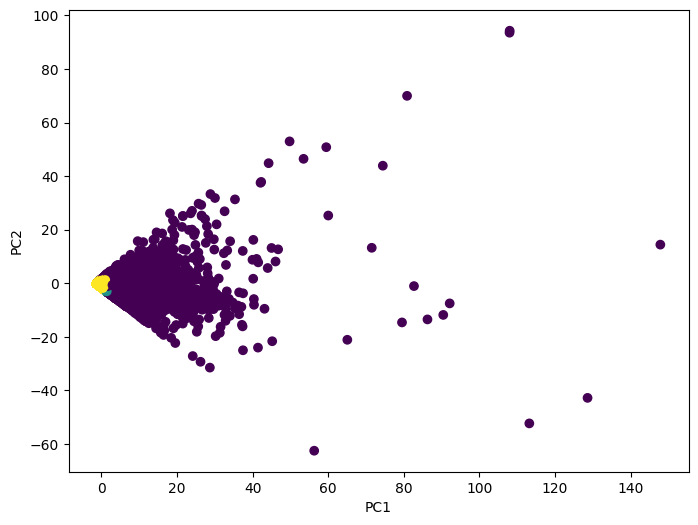

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(df_nutritive_pca[:,0], df_nutritive_pca[:,1], c=labels_hdb)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Ocene klasterovanja

In [34]:
def evaluate(X, labels):
    return {
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels)
    }

In [35]:
print(evaluate(df_nutritive_pca, clusters))
print(evaluate(df_nutritive_pca, labels_bisect))
mask = labels_hdb != -1
print(evaluate(df_nutritive_pca[mask], labels_hdb[mask]))

{'silhouette': 0.7713289051712995, 'davies_bouldin': 0.9969997223427761, 'calinski_harabasz': 90043.2219287428}
{'silhouette': 0.8523529446362696, 'davies_bouldin': 1.0015704682337325, 'calinski_harabasz': 84374.8479021165}
{'silhouette': 0.7366054575385805, 'davies_bouldin': 0.24488263195686844, 'calinski_harabasz': 5045.09214773951}


# Klasterovanje po sastojcima

In [6]:
df_ingredients = df_recipes_reduced_ingredients.loc[:,df_recipes_reduced_ingredients.columns.str.startswith('ing')]

In [7]:
df_ingredients = df_ingredients.drop(columns = ["ingredients", "ingredients_list"])

# KMeans

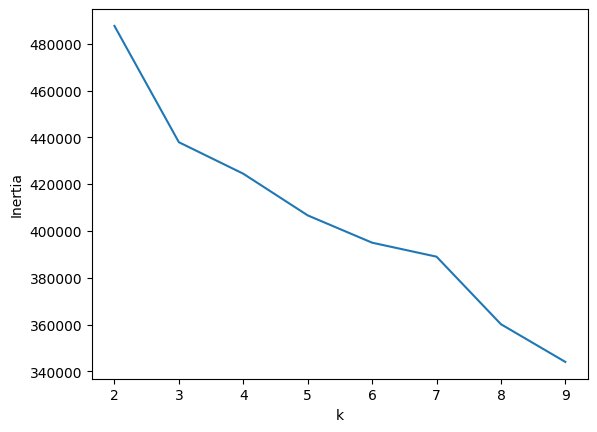

In [30]:
inertia = []
for k in range(2 ,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_ingredients)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

Silueta na skupu 

In [9]:
idx = np.random.choice(len(df_ingredients), 15000, replace=False)

for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_ingredients)
    score = silhouette_score(df_ingredients.iloc[idx],labels[idx], metric="cosine")
    print(k, score)

2 0.07800991140413398
3 0.0668349558931966
4 0.0666522045253856
5 0.09229947822852379
6 0.0852877802154517
7 0.07686806112434015
8 0.10887601274948183


In [10]:
pd.Series(labels).value_counts()

3    95977
1    29005
2    21033
5    20524
6    17612
4    15567
0    15207
7    14709
Name: count, dtype: int64

In [11]:
df_dense = df_ingredients.sparse.to_dense().astype(float)
df_dense["cluster"] = labels

cluster_profile = df_dense.groupby("cluster").mean()
for c in cluster_profile.index:
    print(f"\nCluster {c}")
    print(cluster_profile.loc[c].sort_values(ascending=False).head(5))


Cluster 0
ing_milk      1.000000
ing_butter    0.403696
ing_salt      0.263037
ing_eggs      0.257053
ing_sugar     0.199645
Name: 0, dtype: float64

Cluster 1
ing_onion            1.000000
ing_salt             0.300500
ing_garlic cloves    0.248647
ing_olive oil        0.241269
ing_water            0.201241
Name: 1, dtype: float64

Cluster 2
ing_sugar     1.000000
ing_salt      0.289973
ing_water     0.277516
ing_butter    0.182808
ing_eggs      0.124043
Name: 2, dtype: float64

Cluster 3
ing_salt             0.186086
ing_butter           0.169155
ing_water            0.129479
ing_garlic cloves    0.084010
ing_brown sugar      0.073017
Name: 3, dtype: float64

Cluster 4
ing_flour     0.957474
ing_salt      0.765851
ing_sugar     0.661849
ing_butter    0.619194
ing_eggs      0.528169
Name: 4, dtype: float64

Cluster 5
ing_olive oil          1.000000
ing_salt               0.321136
ing_garlic cloves      0.278990
ing_garlic             0.173748
ing_salt and pepper    0.145488
Name: 5, 

Cluster 0: Mlečni recepti 

Cluster 1: Slana jela sa bazom od luka i belog luka

Cluster 2: Slatki recepti sa dominantnim šećerom

Cluster 3: Opšti / osnovni recepti 

Cluster 4: Kolači i testa sa visokim udelom brašna 

Cluster 5: Mediteranski stil sa maslinovim uljem 

Cluster 6: Jela sa naglašenim začinima – biber i so 

Cluster 7: Brza testa i peciva sa praškom za pecivo 

In [12]:
df_dense['cluster'] = labels
cluster_profile = df_dense.groupby('cluster').mean()

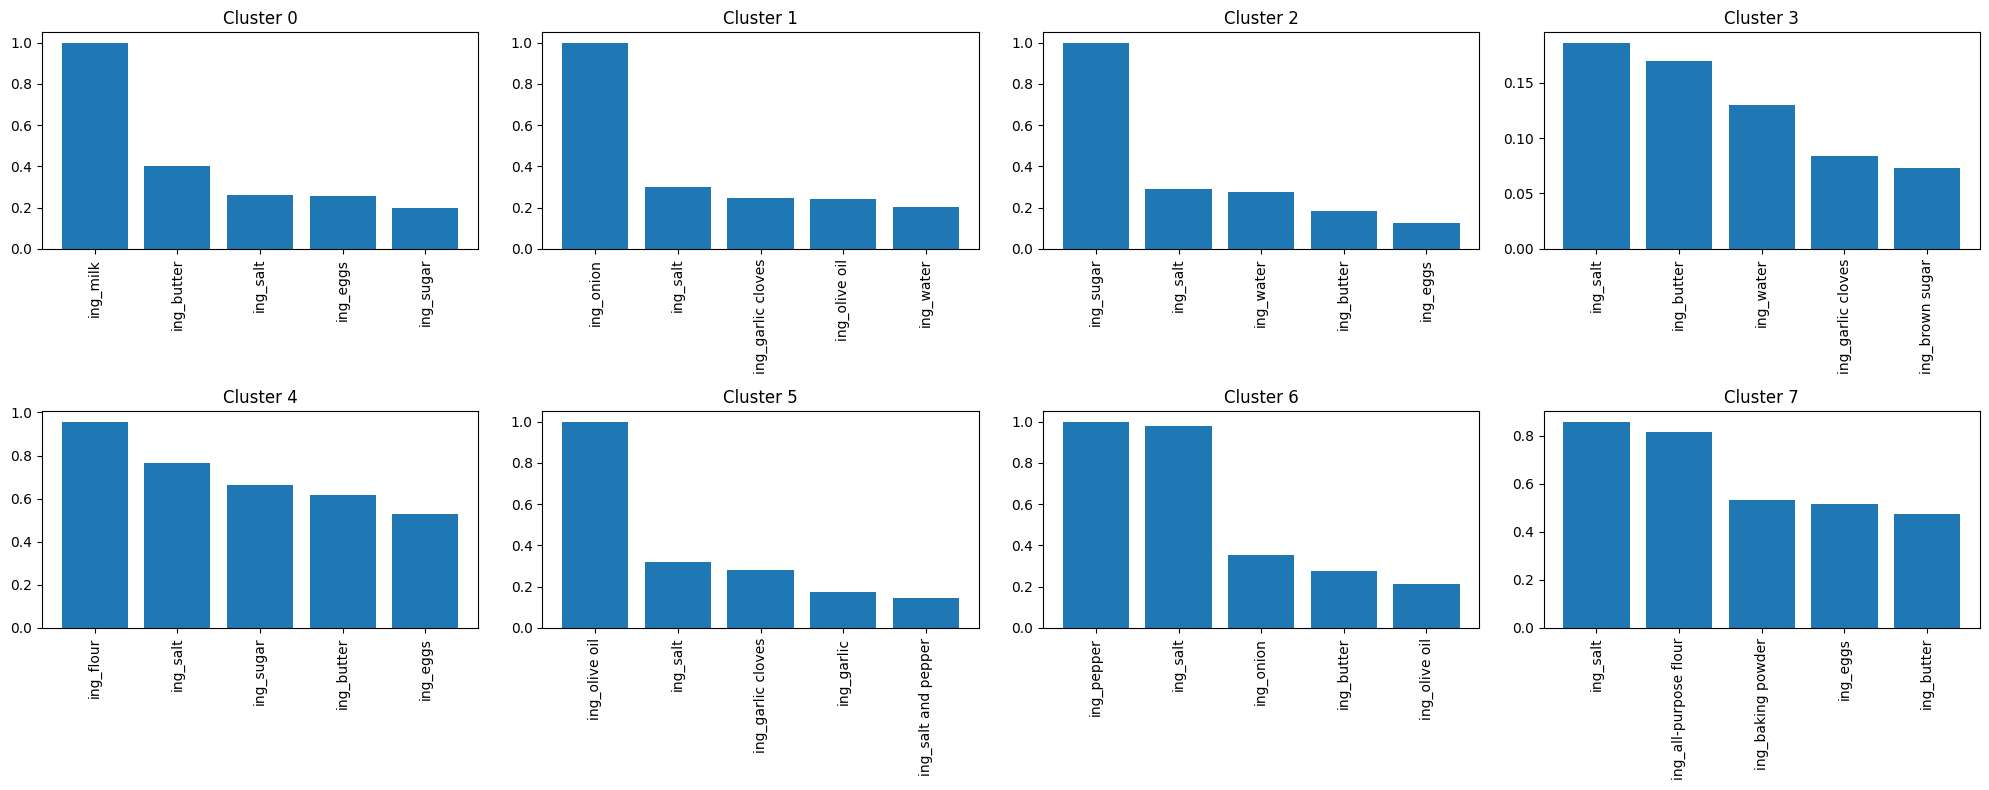

In [104]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, cluster_id in enumerate(cluster_profile.index):
    top_ingredients = (
        cluster_profile.loc[cluster_id]
        .sort_values(ascending=False)
        .head(5)
    )
    
    axes[i].bar(top_ingredients.index, top_ingredients.values)
    axes[i].set_title(f"Cluster {cluster_id}")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

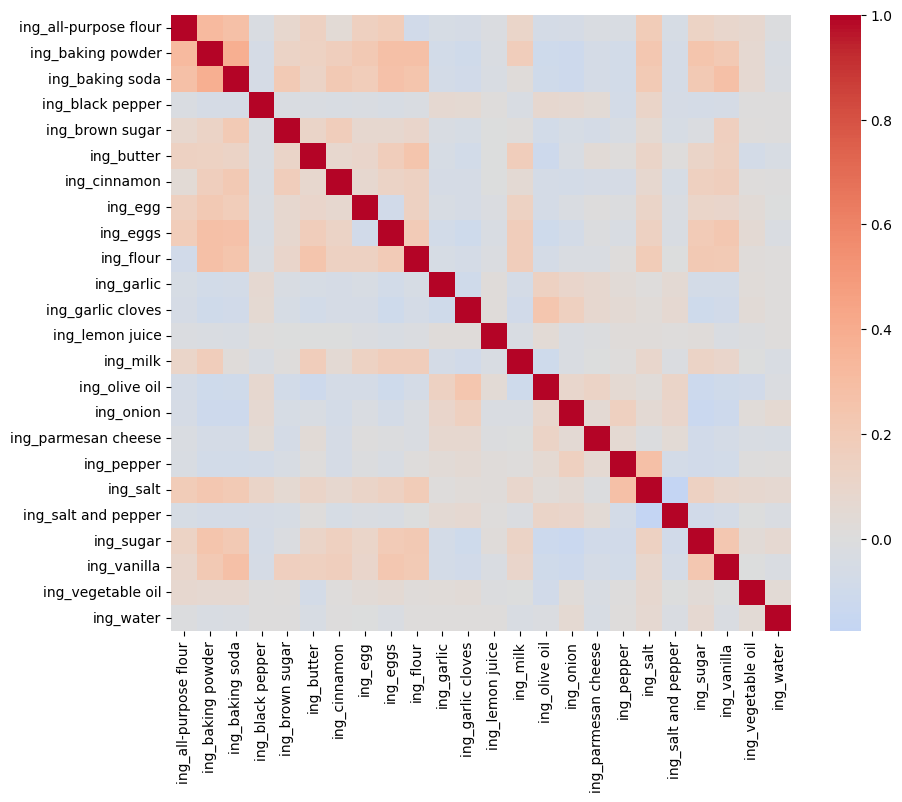

In [13]:
corr = df_dense.corr()
corr = df_dense.drop(columns="cluster").corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

# Klasterovanje numeričkih podataka

In [14]:
df_numerical = df_recipes_reduced_ingredients[['minutes', 'n_steps', 'n_ingredients']].copy()

In [15]:
scaler = StandardScaler()
df_numerical_scaled = scaler.fit_transform(df_numerical)

Metoda lakta

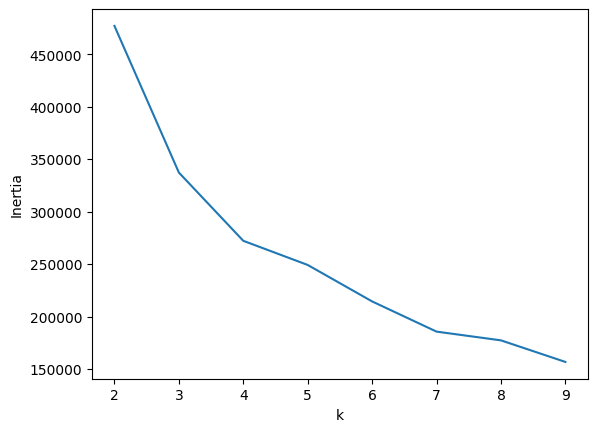

In [132]:
inertia = []
for k in range(2 ,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_numerical_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()


# KMeans

In [45]:
kmeans3 = KMeans(n_clusters=3, random_state=42)
kmeans4 = KMeans(n_clusters=4, random_state=42)
labels3 = kmeans3.fit_predict(df_numerical_scaled)
labels4 = kmeans4.fit_predict(df_numerical_scaled)

df_numerical['clusters3'] = labels3
df_numerical['clusters4'] = labels4

In [139]:
df_numerical.groupby('clusters3').mean()

,minutes,n_steps,n_ingredients,clusters4
clusters3,,,,
0,39.085243,6.958314,7.109888,0.237244
1,66.464872,14.814616,12.526289,1.678071
2,486.834632,9.468304,9.498981,1.995686


In [140]:
df_numerical.groupby('clusters4').mean()

,minutes,n_steps,n_ingredients,clusters3
clusters4,,,,
0,36.020202,6.643455,6.209516,0.001385
1,55.382291,10.067607,11.404652,0.607299
2,492.026813,9.214630,9.445323,1.998394
3,82.324024,21.416592,12.957551,1.003686


Cluster 0 : Brzi i jednostavni

Cluster 1 : Srednje kompleksni

Cluster 2 : Jako kompleksni

Cluster 3 : Ekstremno dugi

In [141]:
df_numerical['clusters4'].value_counts()

clusters4
0    108999
1     85686
3     26856
2      8093
Name: count, dtype: int64

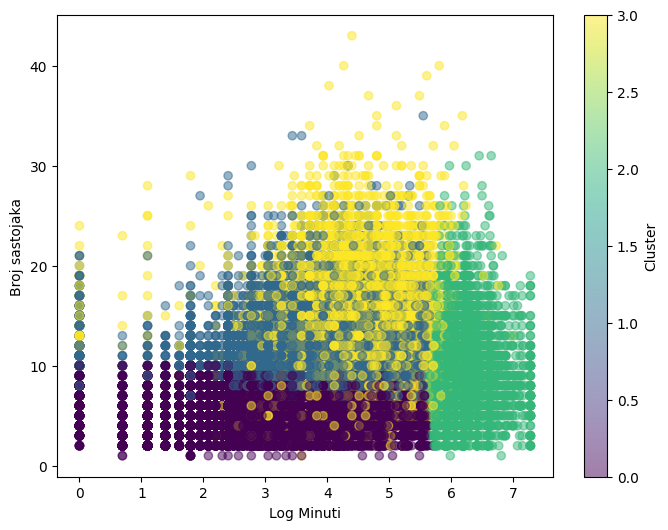

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    np.log1p(df_numerical['minutes']),
    df_numerical['n_ingredients'],
    c=df_numerical['clusters4'],
    cmap='viridis',
    alpha=0.5
)

plt.xlabel("Log Minuti")
plt.ylabel("Broj sastojaka")
plt.colorbar(label="Cluster")
plt.show()

In [46]:
df_recipes_reduced_ingredients['cluster'] = df_numerical['clusters4']

In [144]:
df_recipes_reduced_ingredients.groupby('cluster').agg({
    'avg_rating': 'mean',
    'minutes': 'mean',
    'n_steps': 'mean',
    'n_ingredients': 'mean'
})

,avg_rating,minutes,n_steps,n_ingredients
cluster,,,,
0,4.364486,36.020202,6.643455,6.209516
1,4.348296,55.382291,10.067607,11.404652
2,4.220462,492.026813,9.214630,9.445323
3,4.314310,82.324024,21.416592,12.957551


In [145]:
df_recipes_reduced_ingredients.groupby('cluster')['avg_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,108999.0,4.364486,0.968521,0.0,4.0,4.75,5.0,5.0
1,85686.0,4.348296,0.974865,0.0,4.0,4.67,5.0,5.0
2,8093.0,4.220462,1.041761,0.0,4.0,4.50,5.0,5.0
3,26856.0,4.314310,1.084529,0.0,4.0,4.80,5.0,5.0


In [164]:
n_iterations = 30
ari_scores = []
k = 4

n = df_numerical_scaled.shape[0]

for i in range(n_iterations):
    
    sample_idx = np.random.choice(n, size=n, replace=True)
    sample_data = df_numerical_scaled[sample_idx]
    
    kmeans_boot = KMeans(n_clusters=k, random_state=42)
    boot_labels = kmeans_boot.fit_predict(sample_data)
    
    boot_full_labels = kmeans_boot.predict(df_numerical_scaled)

    ari = adjusted_rand_score(labels4, boot_full_labels)
    ari_scores.append(ari)

print("Prosečni ARI:", np.mean(ari_scores))
print("Std ARI:", np.std(ari_scores))

Prosečni ARI: 0.3131201032200087
Std ARI: 0.014983856087680247


Ne postoje oštre granice između tipova recepata

# GaussianMixture

In [165]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(df_numerical_scaled)

df_numerical['gmm_cluster'] = gmm_labels

In [168]:
probs = gmm.predict_proba(df_numerical_scaled)
np.mean(np.max(probs, axis=1))

0.8496123526714865

# Klasterovanje na recenzijama

In [37]:
df_all_reviews.columns

Index(['user_id', 'recipe_id', 'date', 'rating', 'review', 'name', 'minutes',
       'contributor_id', 'submitted', 'tags', 'n_steps', 'steps',
       'description', 'ingredients', 'n_ingredients', 'n_tags', 'calories',
       'fat', 'sugar', 'sodium', 'protein', 'saturated fat', 'carbohydrates'],
      dtype='object')

In [38]:
user_stats = df_all_reviews.groupby('user_id').agg({
    'rating': ['mean', 'count', 'std']
})

user_stats.columns = ['user_avg_rating', 'user_n_reviews', 'user_rating_std']
user_stats = user_stats.reset_index()

In [39]:
user_stats.isna().sum()

user_id                 0
user_avg_rating         0
user_n_reviews          0
user_rating_std    165260
dtype: int64

In [40]:
user_stats = user_stats[user_stats['user_n_reviews'] > 1]

In [41]:
scaler = StandardScaler()
X_user = scaler.fit_transform(user_stats[['user_avg_rating',
                                          'user_n_reviews',
                                          'user_rating_std']])

kmeans_users = KMeans(n_clusters=3, random_state=42)
user_stats['user_cluster'] = kmeans_users.fit_predict(X_user)

In [42]:
evaluate(X_user, user_stats['user_cluster'])

{'silhouette': 0.6417091507076351,
 'davies_bouldin': 0.6245719261612775,
 'calinski_harabasz': 46764.0457165259}

In [43]:
user_stats.groupby('user_cluster').mean()

,user_id,user_avg_rating,user_n_reviews,user_rating_std
user_cluster,,,,
0,2.622531e+08,2.752669,5.387482,2.236332
1,1.286449e+08,4.711267,14.147989,0.422425
2,2.507582e+05,4.678411,1422.668750,0.656694


Cluster 0 : Kritičari (daju i 1 i 5)

Cluster 1 : Korisnici sa pozitivnim ocenama

Cluster 2 : Korisnici sa ogromnim brojem recenzija


In [47]:
ct =pd.crosstab(user_stats['user_cluster'],df_recipes_reduced_ingredients['cluster'])

In [48]:
ct_norm = ct.div(ct.sum(axis=1), axis=0)

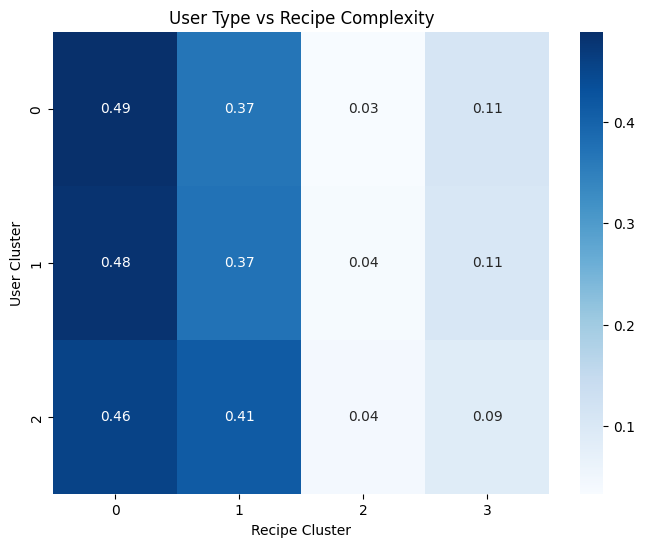

In [49]:
plt.figure(figsize=(8,6))
sns.heatmap(ct_norm, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Recipe Cluster")
plt.ylabel("User Cluster")
plt.title("User Type vs Recipe Complexity")
plt.show()

In [74]:
df_all_reviews = df_all_reviews[df_all_reviews['review'].str.strip() != ""]

In [75]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df_all_reviews['clean_review'] = df_all_reviews['review'].apply(clean_text)

In [76]:
vectorizer = TfidfVectorizer(
    stop_words='english', 
    max_features=4000,
    ngram_range=(1,2),
    min_df=5
)
X_text = vectorizer.fit_transform(df_all_reviews['clean_review'])

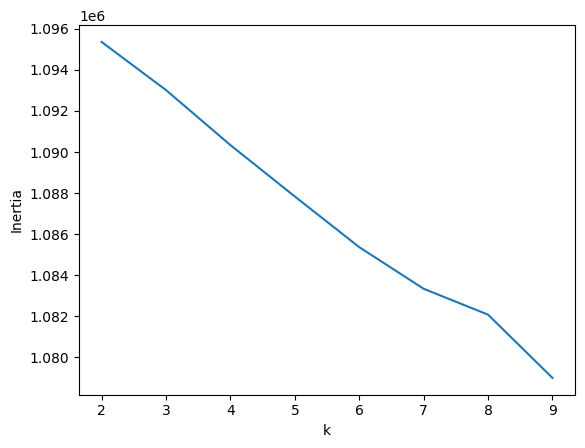

In [77]:
inertia = []
for k in range(2 ,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_text)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [78]:
kmeans_text = KMeans(n_clusters=4, random_state=42)
df_all_reviews['text_cluster'] = kmeans_text.fit_predict(X_text)

In [86]:
sample_size = 10000
idx = np.random.choice(X_text.shape[0], sample_size, replace=False)

sil = silhouette_score(
    X_text[idx],
    df_all_reviews['text_cluster'].iloc[idx],
    metric='cosine'
)

print("Silhouette (sample):", sil)

Silhouette (sample): 0.0057699520771409395


Niska ocena, jer su generalno svi komentari pozitivni

In [88]:
kmeans_text = KMeans(n_clusters=3, random_state=42)
df_all_reviews['text_cluster3'] = kmeans_text.fit_predict(X_text)

In [89]:
sample_size = 10000
idx = np.random.choice(X_text.shape[0], sample_size, replace=False)

sil = silhouette_score(
    X_text[idx],
    df_all_reviews['text_cluster3'].iloc[idx],
    metric='cosine'
)

print("Silhouette (sample):", sil)

Silhouette (sample): 0.00516188557298454


In [79]:
(pd.crosstab(df_all_reviews['text_cluster'],df_all_reviews['rating'],normalize='index') * 100).round(1)

rating,0,1,2,3,4,5
text_cluster,,,,,,
0,4.4,0.6,1.1,4.4,23.1,66.5
1,2.9,0.2,0.4,2.3,17.7,76.6
2,5.0,0.5,0.8,2.0,9.5,82.2
3,6.5,1.7,1.6,3.7,13.5,73.1


In [80]:
df_all_reviews.groupby('text_cluster')[['calories','fat','sugar','protein']].mean()

,calories,fat,sugar,protein
text_cluster,,,,
0,435.902741,34.388308,41.851911,44.276181
1,435.789657,32.641817,72.373083,35.075810
2,431.895361,32.682307,75.617847,31.621563
3,477.082184,35.259044,98.168498,31.321009


In [81]:
df_all_reviews.groupby('text_cluster')[['minutes','n_steps','n_ingredients']].mean()

,minutes,n_steps,n_ingredients
text_cluster,,,
0,79.495842,9.406642,9.591885
1,66.192309,9.020837,8.152827
2,63.452657,9.319038,8.719521
3,67.720462,9.882415,8.783069


In [82]:
df_all_reviews['review_length'] = df_all_reviews['clean_review'].str.split().apply(len)
df_all_reviews.groupby('text_cluster')['review_length'].mean()

text_cluster
0    64.060404
1    38.147805
2    46.698141
3    46.853646
Name: review_length, dtype: float64

In [83]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans_text.cluster_centers_.argsort()[:, ::-1]

In [84]:
for i in range(4):
    print(f"\nKlaster {i}:")
    for ind in order_centroids[i, :15]:
        print(terms[ind])


Klaster 0:
used
sauce
added
good
chicken
recipe
little
time
instead
cheese
garlic
really
add
great
did

Klaster 1:
easy
easy make
make
recipe
quick
thanks
great
delicious
good
quick easy
tasty
loved
really
used
good easy

Klaster 2:
love
recipe
thanks
love recipe
great
just
make
good
like
used
time
use
delicious
really
thank

Klaster 3:
recipe
great
thanks
good
make
just
loved
delicious
like
time
really
used
thank
wonderful
sharing
